In [1]:
from google.colab import drive

drive.mount("/content/drive")
path = "/content/drive/MyDrive/Datasheet/credit_card_fraud_10k.csv"

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
df.drop(columns="transaction_id", inplace=True)

In [4]:
df.isnull().sum()

,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [6]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [7]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [8]:
df.head(5)

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [9]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

**Feature Engineering**

In [10]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour']/24)

In [11]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [12]:
Feature = ['amount','hour_sin','hour_cos', 'foreign_transaction', 'location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f" Jumlah data training : {len(X_train)} dan Jumlah data uji : {len(X_test)}")

 Jumlah data training : 8000 dan Jumlah data uji : 2000


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [15]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [16]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_baseline = AdaBoostClassifier(random_state=42)

**Model Baseline**

In [18]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', adaboost_baseline)
])

In [19]:
baseline_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', AdaBoostClassifier(random_state=42))])

In [20]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f'Akurasi model baseline adalah : {accuracy_baseline:.4f}')
print(f'Precision model baseline adalah : {precision_baseline:.4f}')
print(f'Recall model baseline adalah : {recall_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline))

Akurasi model baseline adalah : 0.9995
Precision model baseline adalah : 1.0000
Recall model baseline adalah : 0.9667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.97      0.98        30

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



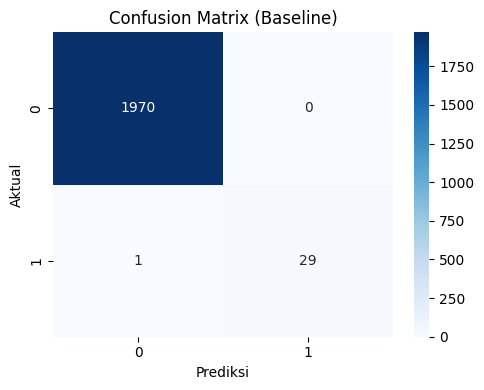

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [23]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]

In [24]:
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f"ROC AUC score model baseline : {roc_auc_baseline:.4f}")

ROC AUC score model baseline : 1.0000


**AdaBoost + SMOTE**

In [26]:
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = imbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', adaboost_baseline)
])

In [27]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', AdaBoostClassifier(random_state=42))])

In [28]:
y_pred_smote = smote_pipeline.predict(X_test)

In [29]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f'Akurasi model SMOTE adalah : {accuracy_smote:.4f}')
print(f'Precision model SMOTE adalah : {precision_smote:.4f}')
print(f'Recall model SMOTE adalah : {recall_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Akurasi model SMOTE adalah : 0.9925
Precision model SMOTE adalah : 0.6667
Recall model SMOTE adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1970
           1       0.67      1.00      0.80        30

    accuracy                           0.99      2000
   macro avg       0.83      1.00      0.90      2000
weighted avg       0.99      0.99      0.99      2000



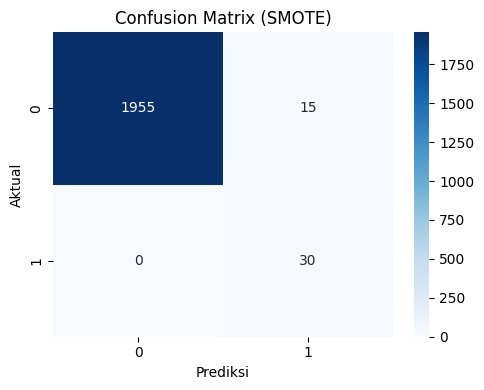

In [30]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [31]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

In [32]:
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f"ROC AUC score model SMOTE : {roc_auc_smote:.4f}")

ROC AUC score model SMOTE : 1.0000


**Model Hyperparameter Tuning Menggunakan Model Baseline**

In [34]:
params_grid = {
    'model__n_estimators' : [50, 100, 200],
    'model__learning_rate' : [0.01, 0.1, 0.5, 1],
    'model__algorithm' : ['SAMME', 'SAMME.R']
}

In [35]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=params_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [36]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('model',
                                        AdaBoostClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__algorithm': ['SAMME', 'SAMME.R'],
                         'model__learning_rate': [0.01, 0.1, 0.5, 1],
                         'model__n_estimators': [50, 100, 200]},
             scoring='f1', verbose=1)

In [37]:
print(grid_search.best_params_)

{'model__algorithm': 'SAMME', 'model__learning_rate': 1, 'model__n_estimators': 200}


In [38]:
best_adaboost = grid_search.best_estimator_

In [39]:
y_pred = best_adaboost.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Akurasi model adalah : {accuracy:.4f}')
print(f'Precision model adalah : {precision:.4f}')
print(f'Recall model adalah : {recall:.4f}')
print(classification_report(y_test, y_pred))

Akurasi model adalah : 1.0000
Precision model adalah : 1.0000
Recall model adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [41]:
y_prob = best_adaboost.predict_proba(X_test)[:,1]

In [42]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC score model : {roc_auc:.4f}")

ROC AUC score model : 1.0000


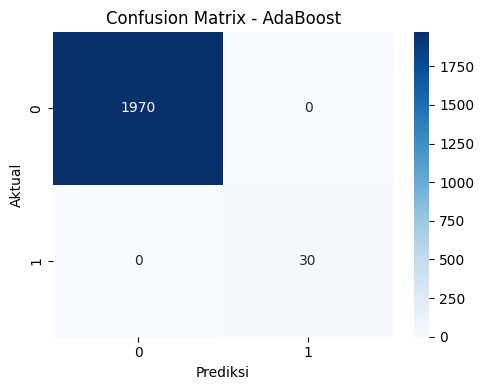

In [43]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix - AdaBoost')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [44]:
feature_names = X.columns

importance = pd.DataFrame({
    'Feature' : feature_names,
    'Importance' : best_adaboost.named_steps['model'].feature_importances_
})

In [45]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [46]:
print(importance)

               Feature  Importance
1             hour_sin    0.186969
0               amount    0.156562
6    velocity_last_24h    0.142985
7       cardholder_age    0.135888
2             hour_cos    0.130383
4    location_mismatch    0.129745
5   device_trust_score    0.108333
3  foreign_transaction    0.009135


/tmp/ipykernel_1416/134645356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


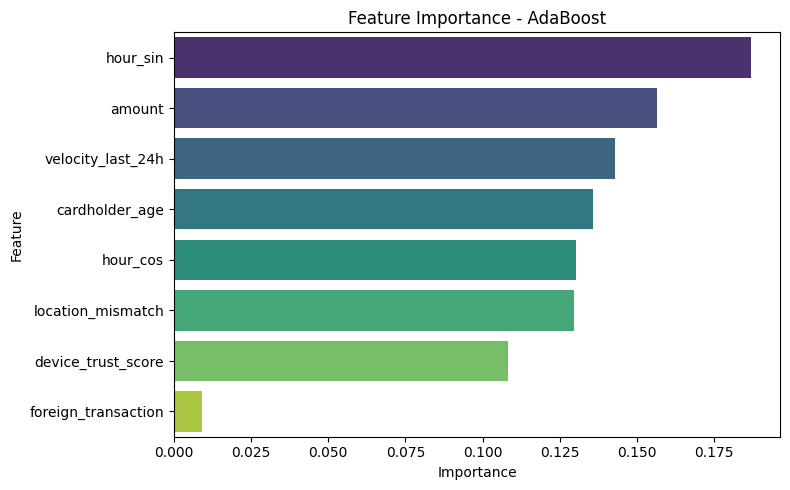

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Feature Importance - AdaBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [50]:
import joblib
from google.colab import files

joblib.dump(best_adaboost, 'AdaBoost_Model.joblib')
files.download('AdaBoost_Model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>